## 2.1
### 1. 向量点积 a·b
a = [2, -1, 3]^T，b = [1, 4, -2]^T
a·b = 2×1 + (-1)×4 + 3×(-2) = 2 - 4 - 6 = **-8**

### 2. 矩阵乘法 A×B
A: 2×3，B: 3×2 → 结果形状 **2×2**
A×B = [[1×2+0×0+2×3, 1×1+0×(-1)+2×2],
       [-1×2+3×0+1×3, -1×1+3×(-1)+1×2]]
     = [[8, 5],
        [1, -2]]

### 3. 向量a的Frobenius范数
||a||_F = √(2² + (-1)² + 3²) = √(4+1+9) = **√14**

In [1]:
# HW01_2_2.py
import numpy as np

# 1. 创建形状为 3x4 的随机矩阵 X，服从标准正态分布
np.random.seed(42)  # 固定随机种子，便于复现
X = np.random.randn(3, 4)

# 2. 创建形状为 4x2 的全 1 矩阵 Y
Y = np.ones((4, 2))

# 3. 计算矩阵乘法 Z = X @ Y
Z = X @ Y

# 4. 输出 Z 的第一行第二列交叉处的元素，以及 Z 的第 2 行所有元素
print("Z 的第一行第二列元素:", Z[0, 1])
print("Z 的第 2 行所有元素:", Z[1, :])

# 5. 计算 Z 的 Frobenius 范数
frob_norm = np.linalg.norm(Z, 'fro')
print("Z 的 Frobenius 范数:", frob_norm)

Z 的第一行第二列元素: 2.5291682463487657
Z 的第 2 行所有元素: [1.87835721 1.87835721]
Z 的 Frobenius 范数: 4.616873319476863


## 3.1
设 A=患病，B=阳性
P(A)=0.001，P(¬A)=0.999
P(B|A)=0.99，P(B|¬A)=0.02

P(A|B) = [P(A)P(B|A)] / [P(A)P(B|A)+P(¬A)P(B|¬A)]
= (0.001×0.99) / (0.001×0.99 + 0.999×0.02)
≈ **0.0472**（4.72%）

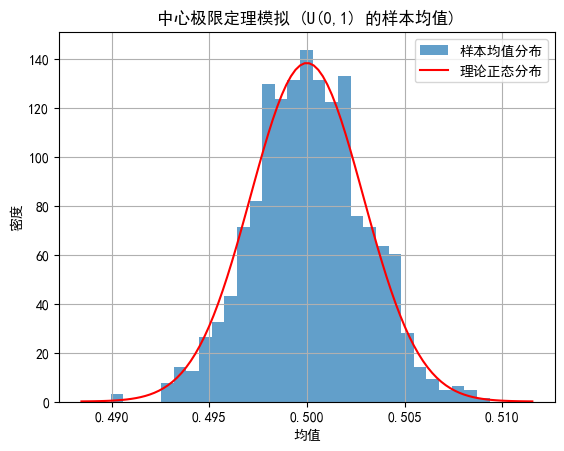

实际均值: 0.500128
实际方差: 0.00000820
理论方差: 0.00000833


In [4]:
# HW01_3_2.py
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
# 参数
n = 10000   # 每次抽取的样本量
m = 1000    # 重复次数

# 生成 m 个均值
means = []
for _ in range(m):
    sample = np.random.uniform(0, 1, n)
    means.append(np.mean(sample))
means = np.array(means)

# 绘制直方图
plt.hist(means, bins=30, density=True, alpha=0.7, label='样本均值分布')

# 理论正态分布：均值 = 0.5，方差 = (1/12)/n
mu_theory = 0.5
sigma_theory = np.sqrt((1/12) / n)
x = np.linspace(mu_theory - 4*sigma_theory, mu_theory + 4*sigma_theory, 100)
plt.plot(x, norm.pdf(x, mu_theory, sigma_theory), 'r-', label='理论正态分布')

plt.xlabel('均值')
plt.ylabel('密度')
plt.title('中心极限定理模拟 (U(0,1) 的样本均值)')
plt.legend()
plt.grid(True)
plt.show()

# 计算这些均值的实际方差
actual_var = np.var(means, ddof=1)  # 样本方差
print(f"实际均值: {np.mean(means):.6f}")
print(f"实际方差: {actual_var:.8f}")
print(f"理论方差: {sigma_theory**2:.8f}")

## 4.1
z = (w₁x₁ + w₂x₂ − y)²，x₁=2,x₂=1,y=3
∂z/∂w₁ = 2x₁(w₁x₁ + w₂x₂ − y)
∂z/∂w₂ = 2x₂(w₁x₁ + w₂x₂ − y)

代入 w₁=0.5, w₂=1：
内部 = 0.5×2 +1×1 −3 = 1+1−3 = -1
∂z/∂w₁ = 2×2×(-1) = **-4**
∂z/∂w₂ = 2×1×(-1) = **-2**

In [5]:
# HW01_4_2.py
import torch

# ---------- 前向计算 ----------
x = 2.0
w1 = 1.5
w2 = 0.5

a = x * w1
b = a + w2
L = b ** 2

print(f"前向结果 L = {L}")

# ---------- 手动计算梯度（链式法则）----------
# dL/db = 2*b
# db/da = 1, da/dw1 = x, db/dw2 = 1
# 所以:
# dL/dw1 = dL/db * db/da * da/dw1 = 2*b * 1 * x = 2*b*x
# dL/dw2 = dL/db * db/dw2 = 2*b * 1 = 2*b

b_val = b  # 此时 b = 2*1.5 + 0.5 = 3.5
grad_w1_manual = 2 * b_val * x   # 2*3.5*2 = 14.0
grad_w2_manual = 2 * b_val       # 2*3.5 = 7.0

print(f"手动梯度: dw1 = {grad_w1_manual}, dw2 = {grad_w2_manual}")

# ---------- 自动微分验证 (PyTorch) ----------
x_t = torch.tensor(x, requires_grad=False)
w1_t = torch.tensor(w1, requires_grad=True)
w2_t = torch.tensor(w2, requires_grad=True)

a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2
L_t.backward()

print(f"自动微分梯度: dw1 = {w1_t.grad.item()}, dw2 = {w2_t.grad.item()}")

# 验证是否一致
assert abs(grad_w1_manual - w1_t.grad.item()) < 1e-6
assert abs(grad_w2_manual - w2_t.grad.item()) < 1e-6
print("验证通过：手动梯度与自动微分结果一致。")

前向结果 L = 12.25
手动梯度: dw1 = 14.0, dw2 = 7.0
自动微分梯度: dw1 = 14.0, dw2 = 7.0
验证通过：手动梯度与自动微分结果一致。


## 5.1
L = (1/n)Σ(yᵢ − wxᵢ − b)²
∂L/∂w = (-2/n)Σxᵢ(yᵢ − wxᵢ − b)
∂L/∂b = (-2/n)Σ(yᵢ − wxᵢ − b)


In [8]:
# HW01_5_2.py
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# 1. 加载数据（使用 sklearn 的 digits 数据集，相当于 MNIST 子集）
digits = load_digits()
X = digits.images  # (1797, 8, 8)
y = digits.target
# 展平图像为向量
X = X.reshape(X.shape[0], -1)  # (1797, 64)
# 归一化到 [0,1]
X = X / 16.0

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. One-hot 编码标签
encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_onehot = encoder.transform(y_test.reshape(-1, 1))
num_classes = y_train_onehot.shape[1]

# 3. Softmax 函数和交叉熵损失
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))  # 数值稳定
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    # y_pred: (n, C), y_true: (n, C) one-hot
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

# 4. 小批量梯度下降训练
def train_softmax(X, y_onehot, lr=0.1, batch_size=32, epochs=50, verbose=True):
    n_samples, n_features = X.shape
    n_classes = y_onehot.shape[1]
    # 初始化权重和偏置
    W = np.random.randn(n_features, n_classes) * 0.01
    b = np.zeros((1, n_classes))
    
    losses = []
    for epoch in range(epochs):
        # 随机打乱数据
        indices = np.random.permutation(n_samples)
        X_shuffled = X[indices]
        y_shuffled = y_onehot[indices]
        
        epoch_loss = 0
        for i in range(0, n_samples, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            
            # 前向传播
            logits = X_batch @ W + b
            probs = softmax(logits)
            loss = cross_entropy_loss(probs, y_batch)
            epoch_loss += loss * len(X_batch)
            
            # 反向传播（梯度计算）
            error = probs - y_batch  # (batch_size, n_classes)
            dW = (X_batch.T @ error) / len(X_batch)
            db = np.mean(error, axis=0, keepdims=True)
            
            # 参数更新
            W -= lr * dW
            b -= lr * db
        
        avg_loss = epoch_loss / n_samples
        losses.append(avg_loss)
        if verbose and (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
    return W, b, losses

W, b, losses = train_softmax(X_train, y_train_onehot, lr=0.1, batch_size=32, epochs=50)

# 5. 测试准确率
def predict(X, W, b):
    logits = X @ W + b
    probs = softmax(logits)
    return np.argmax(probs, axis=1)

y_train_pred = predict(X_train, W, b)
y_test_pred = predict(X_test, W, b)
train_acc = np.mean(y_train_pred == y_train)
test_acc = np.mean(y_test_pred == y_test)

print(f"训练集准确率: {train_acc:.4f}")
print(f"测试集准确率: {test_acc:.4f}")

Epoch 10/50, Loss: 0.4562
Epoch 20/50, Loss: 0.3004
Epoch 30/50, Loss: 0.2410
Epoch 40/50, Loss: 0.2077
Epoch 50/50, Loss: 0.1857
训练集准确率: 0.9687
测试集准确率: 0.9639


## 6.1 
1. 似然函数：
L(μ,σ²) = Π[1/√(2πσ²)] exp[−(xᵢ−μ)²/(2σ²)]

2. 对μ求导并令为0，得：
μ̂ = (1/n)Σxᵢ

3. 对σ²求导并令为0，得：
σ̂² = (1/n)Σ(xᵢ−μ̂)²

Iter 200, Loss: 0.314005
Iter 400, Loss: 0.304316
Iter 600, Loss: 0.299739
Iter 800, Loss: 0.296820
Iter 1000, Loss: 0.294839
训练集准确率: 0.8867
测试集准确率: 0.8600


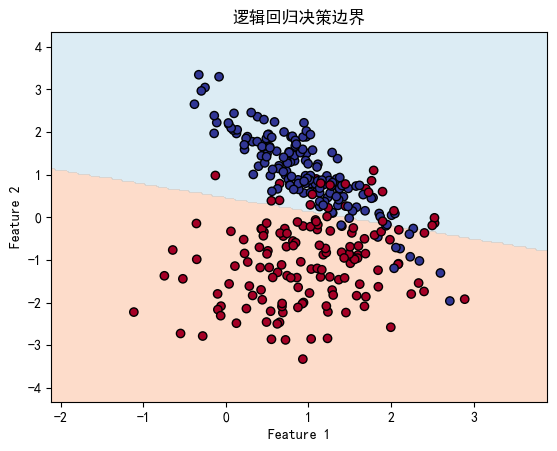

In [9]:
# HW01_6_2.py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# 1. 生成线性可分数据（每类200个，特征2维）
X, y = make_classification(n_samples=400, n_features=2, n_redundant=0, n_informative=2,
                           n_clusters_per_class=1, flip_y=0, random_state=42)
# 将标签转为 0/1
y = y.reshape(-1, 1)

# 划分训练集和测试集（训练300，测试100）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=100, random_state=42)

# 2. 定义 sigmoid 和二元交叉熵损失
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_true, y_pred):
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# 3. 梯度下降训练
def train_logistic_regression(X, y, lr=0.1, n_iter=1000, verbose=True):
    n_samples, n_features = X.shape
    # 初始化参数 w (n_features,1), b (scalar)
    w = np.zeros((n_features, 1))
    b = 0.0
    
    losses = []
    for i in range(n_iter):
        # 前向
        z = X @ w + b
        y_pred = sigmoid(z)
        loss = binary_cross_entropy(y, y_pred)
        losses.append(loss)
        
        # 梯度计算
        dz = y_pred - y  # (n_samples,1)
        dw = (X.T @ dz) / n_samples
        db = np.mean(dz)
        
        # 更新
        w -= lr * dw
        b -= lr * db
        
        if verbose and (i+1) % 200 == 0:
            print(f"Iter {i+1}, Loss: {loss:.6f}")
    return w, b, losses

w, b, losses = train_logistic_regression(X_train, y_train, lr=0.1, n_iter=1000)

# 预测函数
def predict(X, w, b, thresh=0.5):
    prob = sigmoid(X @ w + b)
    return (prob >= thresh).astype(int)

# 测试准确率
y_train_pred = predict(X_train, w, b)
y_test_pred = predict(X_test, w, b)
train_acc = np.mean(y_train_pred == y_train)
test_acc = np.mean(y_test_pred == y_test)
print(f"训练集准确率: {train_acc:.4f}")
print(f"测试集准确率: {test_acc:.4f}")

# 4. 绘制决策边界
def plot_decision_boundary(X, y, w, b):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    Z = sigmoid(np.c_[xx.ravel(), yy.ravel()] @ w + b)
    Z = (Z >= 0.5).reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap=plt.cm.RdYlBu, edgecolors='k')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('逻辑回归决策边界')
    plt.show()

plot_decision_boundary(X_train, y_train, w, b)